# Electric Vehicle Range Prediction

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [11]:
data=pd.read_csv("EV Range Prediction.csv")
data.head()

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Road type,Elevation gain (m),Ambient temp C,AC usage,Driving style,Passenger load,Regen braking level,Real world range (km)
0,59.963210,1392.558526,197.279011,46.865604,City,126.213156,34.972958,Off,Normal,2,Medium,324.978769
1,106.057145,1370.468199,253.303759,45.987009,City,102.793302,19.023683,On,Eco,2,Medium,625.835624
2,88.559515,2359.381871,242.438623,46.712666,City,141.740858,25.464360,Off,Aggressive,3,Medium,512.432610
3,77.892679,1374.319300,96.935977,28.100150,City,78.166710,21.923706,Off,Normal,5,Medium,417.750146
4,42.481491,1407.924589,95.819873,21.049475,City,168.261670,25.517859,Off,Eco,1,High,258.878814


Note: The dataset used is synthetically generated to simulate realistic EV driving conditions.

# Preprocessing

In [12]:
data.shape

(6700, 12)

In [13]:
data.isnull().sum()

Battery capacity (kWh)    0
Vehicle weight (kg)       0
Motor power (kW)          0
Avg speed kmph            0
Road type                 0
Elevation gain (m)        0
Ambient temp C            0
AC usage                  0
Driving style             0
Passenger load            0
Regen braking level       0
Real world range (km)     0
dtype: int64

In [14]:
data.dtypes

Battery capacity (kWh)    float64
Vehicle weight (kg)       float64
Motor power (kW)          float64
Avg speed kmph            float64
Road type                  object
Elevation gain (m)        float64
Ambient temp C            float64
AC usage                   object
Driving style              object
Passenger load              int64
Regen braking level        object
Real world range (km)     float64
dtype: object

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6700 entries, 0 to 6699
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Battery capacity (kWh)  6700 non-null   float64
 1   Vehicle weight (kg)     6700 non-null   float64
 2   Motor power (kW)        6700 non-null   float64
 3   Avg speed kmph          6700 non-null   float64
 4   Road type               6700 non-null   object 
 5   Elevation gain (m)      6700 non-null   float64
 6   Ambient temp C          6700 non-null   float64
 7   AC usage                6700 non-null   object 
 8   Driving style           6700 non-null   object 
 9   Passenger load          6700 non-null   int64  
 10  Regen braking level     6700 non-null   object 
 11  Real world range (km)   6700 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 628.3+ KB


In [16]:
data.describe()

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Elevation gain (m),Ambient temp C,Passenger load,Real world range (km)
count,6700.000000,6700.000000,6700.000000,6700.000000,6700.000000,6700.000000,6700.000000,6700.000000
mean,70.042248,1741.005088,178.696605,64.864583,207.580271,24.338421,3.017313,361.330031
std,23.034694,434.009590,68.329105,28.985960,223.768956,13.005891,1.418639,145.308874
min,30.008819,1000.017452,60.007373,20.040009,0.050491,-4.968613,1.000000,50.000000
25%,49.971694,1365.779429,120.849070,39.090415,75.740487,17.957588,2.000000,236.101488
50%,70.316206,1731.855166,177.768804,60.450420,150.298212,26.322188,3.000000,362.741494
75%,89.972517,2120.288713,237.093770,89.352094,250.985956,34.110491,4.000000,484.334066
max,109.996556,2499.842562,299.935700,119.970747,1199.890766,44.980247,5.000000,674.802344


In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data.nunique()

Battery capacity (kWh)    6700
Vehicle weight (kg)       6700
Motor power (kW)          6700
Avg speed kmph            6700
Road type                    3
Elevation gain (m)        6700
Ambient temp C            6700
AC usage                     2
Driving style                3
Passenger load               5
Regen braking level          3
Real world range (km)     6699
dtype: int64

# EDA

### Driving Style vs Range

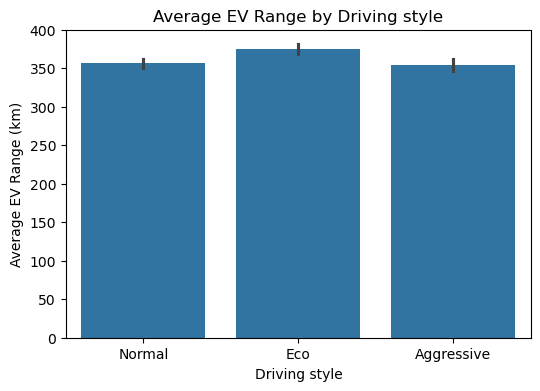

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=data,
    x='Driving style',
    y='Real world range (km)',
    estimator='mean'
)

plt.title("Average EV Range by Driving style")
plt.xlabel("Driving style")
plt.ylabel("Average EV Range (km)")
plt.show()


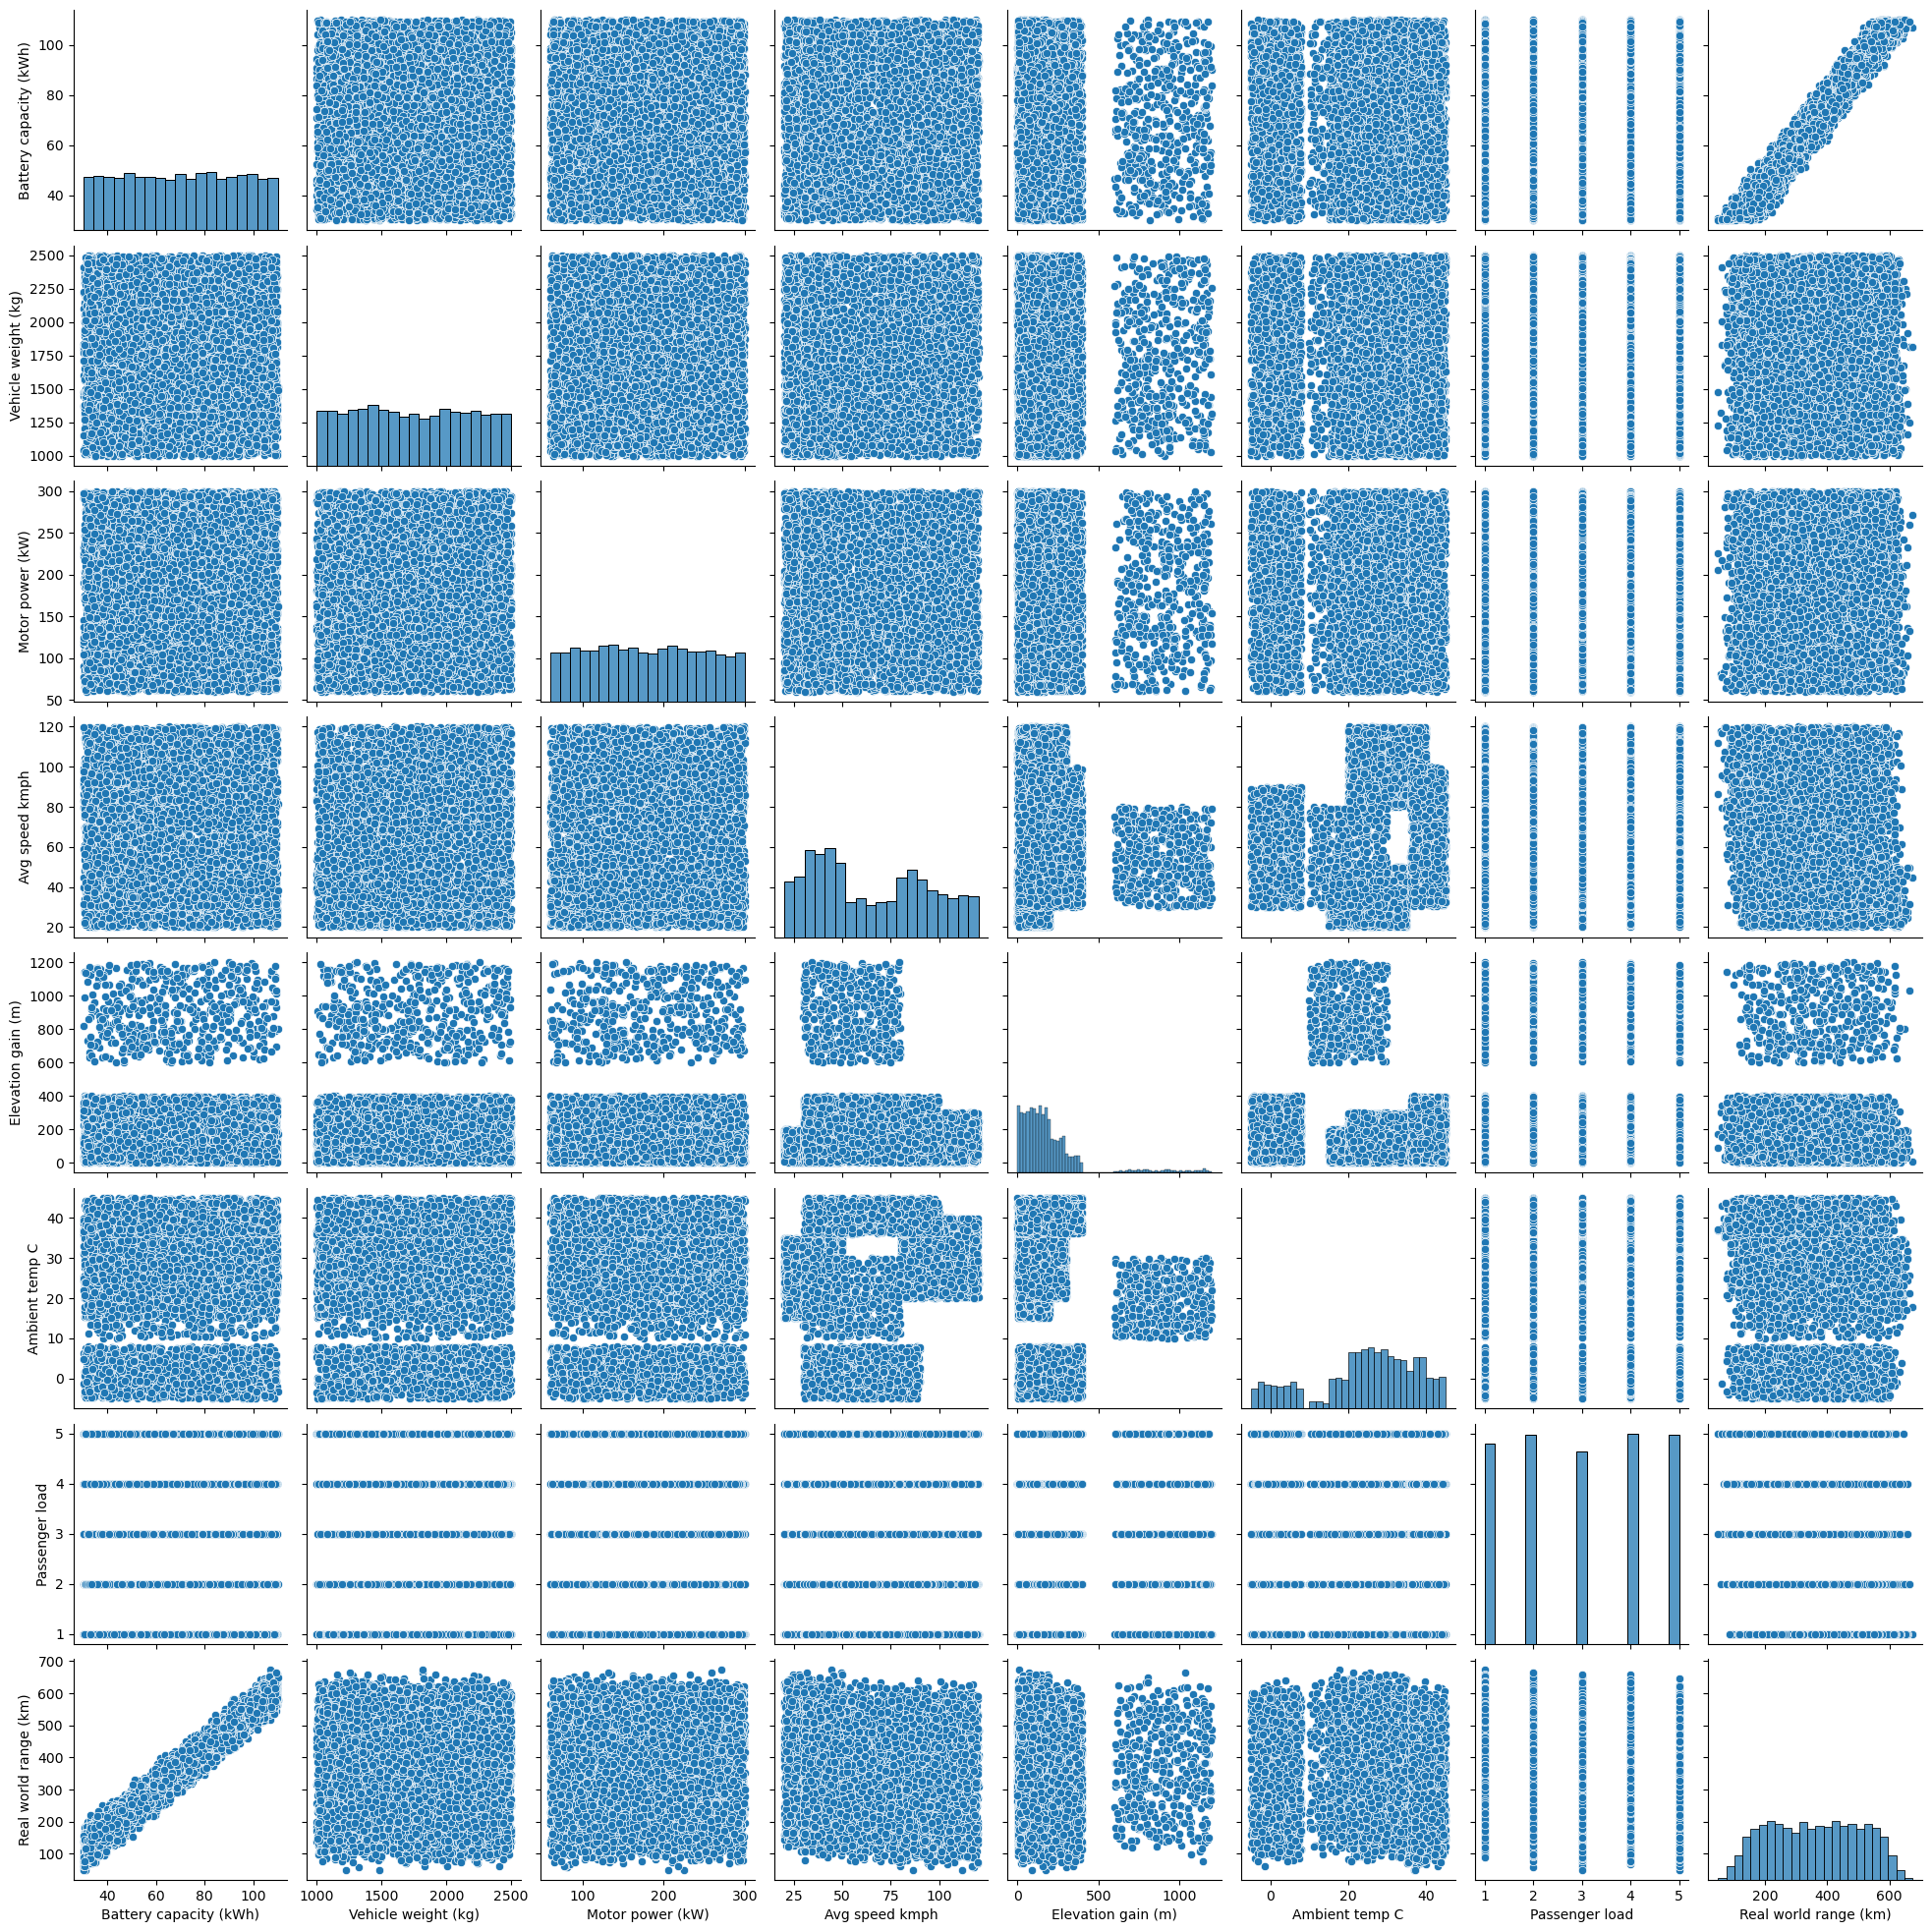

In [20]:
sns.pairplot(data)

### Passenger Load vs Range

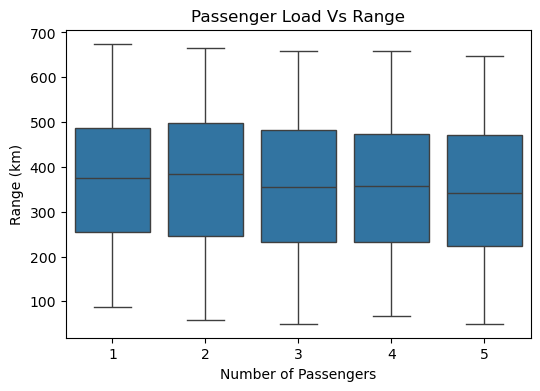

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=data, x="Passenger load", y= "Real world range (km)")
plt.title("Passenger Load Vs Range")
plt.xlabel("Number of Passengers")
plt.ylabel("Range (km)")
plt.show()

### Road Type vs Range

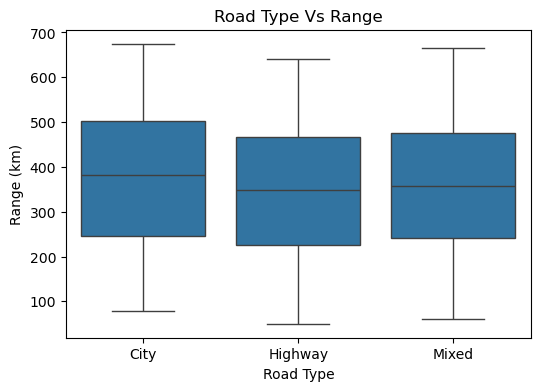

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=data, x="Road type", y="Real world range (km)")
plt.title("Road Type Vs Range")
plt.xlabel("Road Type")
plt.ylabel("Range (km)")
plt.show()

<Axes: >

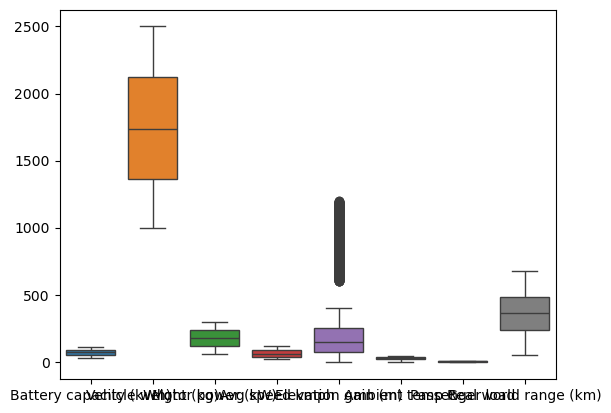

In [23]:
sns.boxplot(data)

From the boxplots, most features such as battery capacity, speed, and real-world range do not show significant outliers. However, the Elevation gain (m) feature shows several values beyond the upper whisker.

To understand this better, I analyzed the elevation gain feature separately.”

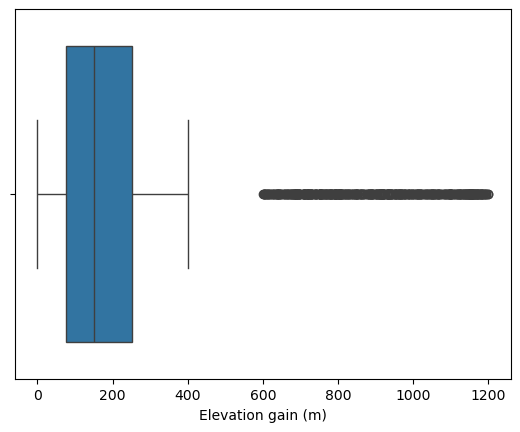

In [24]:
sns.boxplot(x=data['Elevation gain (m)'])
plt.show()

Elevation gain naturally varies depending on terrain. Most trips occur on flat roads, but some trips involve hilly or mountainous regions.

Although elevation gain shows statistical outliers, these values are not errors. They represent valid real-world driving conditions. Removing them would reduce the model’s ability to generalize to hilly or mountainous routes

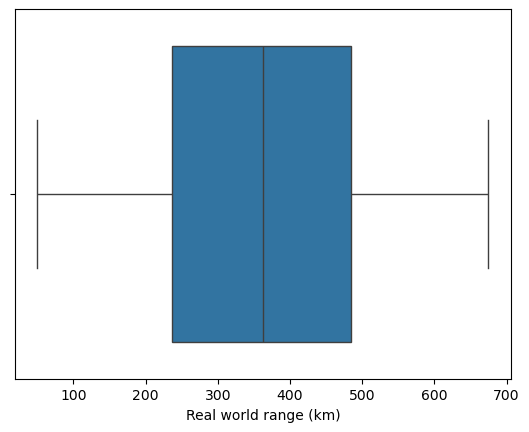

In [25]:
sns.boxplot(x=data['Real world range (km)'])
plt.show()

# Label Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
lbr=LabelEncoder()
lba=LabelEncoder()
lbd=LabelEncoder()
lbl=LabelEncoder()

In [28]:
data.head()

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Road type,Elevation gain (m),Ambient temp C,AC usage,Driving style,Passenger load,Regen braking level,Real world range (km)
0,59.963210,1392.558526,197.279011,46.865604,City,126.213156,34.972958,Off,Normal,2,Medium,324.978769
1,106.057145,1370.468199,253.303759,45.987009,City,102.793302,19.023683,On,Eco,2,Medium,625.835624
2,88.559515,2359.381871,242.438623,46.712666,City,141.740858,25.464360,Off,Aggressive,3,Medium,512.432610
3,77.892679,1374.319300,96.935977,28.100150,City,78.166710,21.923706,Off,Normal,5,Medium,417.750146
4,42.481491,1407.924589,95.819873,21.049475,City,168.261670,25.517859,Off,Eco,1,High,258.878814


In [29]:
data['Road type'] = lbr.fit_transform(data['Road type'])
data['AC usage'] = lba.fit_transform(data['AC usage'])
data['Driving style'] =lbd.fit_transform(data['Driving style'])
data['Regen braking level'] =lbl.fit_transform(data['Regen braking level'])

In [31]:
data.corr()

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Road type,Elevation gain (m),Ambient temp C,AC usage,Driving style,Passenger load,Regen braking level,Real world range (km)
Battery capacity (kWh),1.000000,-0.000865,0.016895,0.003453,-0.002102,0.002593,0.016983,0.007749,-0.029518,-0.008708,0.008352,0.981110
Vehicle weight (kg),-0.000865,1.000000,0.019558,0.010283,-0.014926,0.000204,0.001033,-0.001941,-0.003433,-0.010380,0.013418,-0.006600
Motor power (kW),0.016895,0.019558,1.000000,-0.012330,0.001567,-0.000385,0.005367,-0.018518,-0.004138,0.025896,-0.002780,0.015709
Avg speed kmph,0.003453,0.010283,-0.012330,1.000000,0.384166,-0.025071,0.196818,0.455146,-0.027099,-0.020352,0.204105,-0.099712
Road type,-0.002102,-0.014926,0.001567,0.384166,1.000000,0.502887,-0.068021,0.196222,-0.011666,-0.032625,0.075680,-0.069669
Elevation gain (m),0.002593,0.000204,-0.000385,-0.025071,0.502887,1.000000,-0.117625,-0.077724,-0.011770,-0.014378,-0.019376,-0.007699
Ambient temp C,0.016983,0.001033,0.005367,0.196818,-0.068021,-0.117625,1.000000,0.329852,-0.019801,0.011428,0.049973,-0.007591
AC usage,0.007749,-0.001941,-0.018518,0.455146,0.196222,-0.077724,0.329852,1.000000,-0.010247,-0.006582,0.117398,-0.091151
Driving style,-0.029518,-0.003433,-0.004138,-0.027099,-0.011666,-0.011770,-0.019801,-0.010247,1.000000,-0.013809,-0.007799,-0.008305
Passenger load,-0.008708,-0.010380,0.025896,-0.020352,-0.032625,-0.014378,0.011428,-0.006582,-0.013809,1.000000,-0.014558,-0.076138


<Axes: >

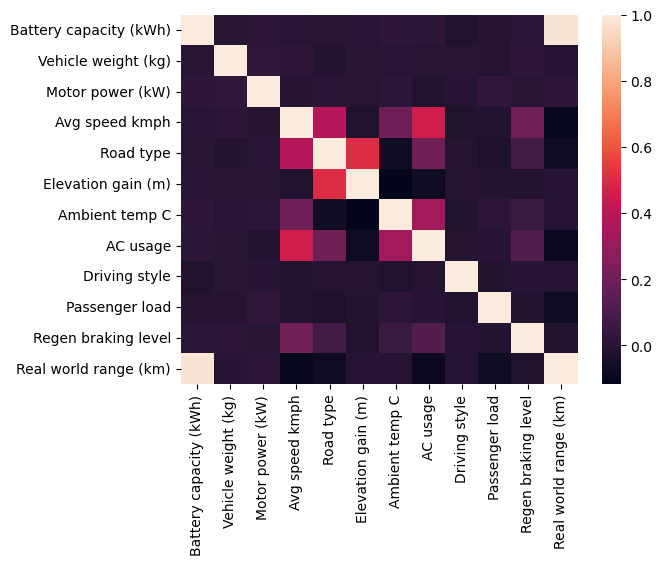

In [32]:
sns.heatmap(data.select_dtypes(['number']).corr())

# Data Splitting

In [33]:
x = data.drop(['Real world range (km)'], axis=1)
x

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Road type,Elevation gain (m),Ambient temp C,AC usage,Driving style,Passenger load,Regen braking level
0,59.963210,1392.558526,197.279011,46.865604,0,126.213156,34.972958,0,2,2,2
1,106.057145,1370.468199,253.303759,45.987009,0,102.793302,19.023683,1,1,2,2
2,88.559515,2359.381871,242.438623,46.712666,0,141.740858,25.464360,0,0,3,2
3,77.892679,1374.319300,96.935977,28.100150,0,78.166710,21.923706,0,2,5,2
4,42.481491,1407.924589,95.819873,21.049475,0,168.261670,25.517859,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6695,34.410255,2069.987941,119.255115,37.447847,2,608.249610,21.461165,0,1,4,1
6696,63.293340,1666.916162,231.339080,43.095338,2,783.505940,28.135000,0,1,1,1
6697,38.951713,1550.002634,187.689747,54.369271,2,638.812002,28.394387,0,2,2,2
6698,88.291163,2394.106299,262.521968,37.239778,2,1155.668730,11.202490,1,1,4,1


In [34]:
y= data['Real world range (km)']
y

0       324.978769
1       625.835624
2       512.432610
3       417.750146
4       258.878814
           ...    
6695    157.085384
6696    361.489217
6697    177.592717
6698    464.956602
6699    540.059469
Name: Real world range (km), Length: 6700, dtype: float64

# Train Test Split

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
data.head()

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Road type,Elevation gain (m),Ambient temp C,AC usage,Driving style,Passenger load,Regen braking level,Real world range (km)
0,59.963210,1392.558526,197.279011,46.865604,0,126.213156,34.972958,0,2,2,2,324.978769
1,106.057145,1370.468199,253.303759,45.987009,0,102.793302,19.023683,1,1,2,2,625.835624
2,88.559515,2359.381871,242.438623,46.712666,0,141.740858,25.464360,0,0,3,2,512.432610
3,77.892679,1374.319300,96.935977,28.100150,0,78.166710,21.923706,0,2,5,2,417.750146
4,42.481491,1407.924589,95.819873,21.049475,0,168.261670,25.517859,0,1,1,0,258.878814


# Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Linear Regression

In [38]:
lr=LinearRegression()
lr

LinearRegression()

In [39]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

print("Linear Regression")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', lr.score(x_train, y_train))
print('Test R2:', lr.score(x_test, y_test))

lr_train_r2 = lr.score(x_train, y_train)
lr_test_r2  = lr.score(x_test, y_test)

Linear Regression
R2 score: 0.9842360405542006
Mean Squared Error: 341.2671227851199
Mean Absolute Error: 14.773714168325451
Train R2: 0.9824668169915467
Test R2: 0.9842360405542006


# Decision Tree

In [40]:
dt=DecisionTreeRegressor(max_depth=3)
dt

DecisionTreeRegressor(max_depth=3)

In [41]:
dt.fit(x_train,y_train)
y_pred1=dt.predict(x_test)
r2 = r2_score(y_test, y_pred1)
mae = mean_absolute_error(y_test,y_pred1)
mse = mean_squared_error(y_test,y_pred1)

print("Decision Tree Regressor")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', dt.score(x_train, y_train))
print('Test R2:', dt.score(x_test, y_test))

dt_train_r2 = dt.score(x_train, y_train)
dt_test_r2  = dt.score(x_test, y_test)


Decision Tree Regressor
R2 score: 0.9473176792972081
Mean Squared Error: 1140.4967178265226
Mean Absolute Error: 27.349921051178914
Train R2: 0.9488859786380848
Test R2: 0.9473176792972081


# Random Forest

In [42]:
rf=RandomForestRegressor(n_estimators=4,random_state=42)
rf

RandomForestRegressor(n_estimators=4, random_state=42)

In [43]:
rf.fit(x_train,y_train)
y_pred2=rf.predict(x_test)

r2 = r2_score(y_test, y_pred2)
mae = mean_absolute_error(y_test,y_pred2)
mse = mean_squared_error(y_test,y_pred2)

print("Random Forest Regressor")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', rf.score(x_train, y_train))
print('Test R2:', rf.score(x_test, y_test))

rf_train_r2 = rf.score(x_train, y_train)
rf_test_r2  = rf.score(x_test, y_test)


Random Forest Regressor
R2 score: 0.980642678268313
Mean Squared Error: 419.0582648294607
Mean Absolute Error: 16.245994734231342
Train R2: 0.9953802580202364
Test R2: 0.980642678268313


# K Nearest Neighbors

In [44]:
knn=KNeighborsRegressor(n_neighbors=5)
knn

KNeighborsRegressor()

In [45]:
knn.fit(X_train_scaled, y_train)
y_pred3=knn.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred3)
mae = mean_absolute_error(y_test,y_pred3)
mse = mean_squared_error(y_test,y_pred3)

print("KNeighbors Regressor")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:',knn.score(X_train_scaled,y_train))
print('Test R2:',knn.score(X_test_scaled,y_test))

knn_train_r2 = knn.score(X_test_scaled,y_test)
knn_test_r2  = knn.score(X_train_scaled,y_train)

KNeighbors Regressor
R2 score: 0.9027646518844826
Mean Squared Error: 2105.005890080124
Mean Absolute Error: 36.484612303897016
Train R2: 0.9320586736886348
Test R2: 0.9027646518844826


# SVR

In [46]:
svm = SVR(kernel='linear')
svm.fit(X_train_scaled, y_train)
y_pred_svr = svm.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_svr)
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)

print("SVR (Linear Kernel)")
print("R² score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print("Train R²:", svm.score(X_test_scaled, y_test))
print("Test R²:", svm.score(X_train_scaled, y_train))

svr_train_r2 = svm.score(X_train_scaled, y_train)
svr_test_r2  = svm.score(X_test_scaled, y_test)

SVR (Linear Kernel)
R² score: 0.9842714246382996
Mean Squared Error: 340.5011080910064
Mean Absolute Error: 14.769141900031743
Train R²: 0.9842714246382996
Test R²: 0.9824423331693075


# AdaBoost

In [47]:
ab = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ab

AdaBoostRegressor(learning_rate=0.1, n_estimators=100, random_state=42)

In [48]:
ab.fit(x_train, y_train)
y_pred4=ab.predict(x_test)

r2 = r2_score(y_test, y_pred4)
mae = mean_absolute_error(y_test,y_pred4)
mse = mean_squared_error(y_test,y_pred4)

print("AdaBoost")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', ab.score(x_train, y_train))
print('Test R2:', ab.score(x_test, y_test))

abr_train_r2 = ab.score(x_train, y_train)
abr_test_r2  = ab.score(x_test, y_test)

AdaBoost
R2 score: 0.9655997601924841
Mean Squared Error: 744.715875639816
Mean Absolute Error: 22.282646243103557
Train R2: 0.9655257281162569
Test R2: 0.9655997601924841


# XG Boost

In [49]:
xgb=XGBRegressor(n_estimators=100, random_state=42)
xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [50]:
xgb.fit(x_train,y_train)
y_pred9=xgb.predict(x_test)

r2 =r2_score(y_test, y_pred9)
mae = mean_absolute_error(y_test, y_pred9)
mse = mean_squared_error(y_test, y_pred9)

print("XG Boost")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', xgb.score(x_train, y_train))
print('Test R2:', xgb.score(x_test, y_test))

xgb_train_r2 = xgb.score(x_train, y_train)
xgb_test_r2  = xgb.score(x_test, y_test)

XG Boost
R2 score: 0.9872344330597457
Mean Squared Error: 276.356223536358
Mean Absolute Error: 13.098828373270162
Train R2: 0.9980835021501703
Test R2: 0.9872344330597457


# Gradient Boosting

In [51]:
gbr=GradientBoostingRegressor(n_estimators=100,learning_rate=0.05,random_state=200)
gbr

GradientBoostingRegressor(learning_rate=0.05, random_state=200)

In [52]:
gbr.fit(x_train,y_train)
y_pred5=gbr.predict(x_test)

r2 = r2_score(y_test, y_pred5)
mae = mean_absolute_error(y_test,y_pred5)
mse = mean_squared_error(y_test,y_pred5)

print("Gradient Boosting")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', gbr.score(x_train, y_train))
print('Test R2:', gbr.score(x_test, y_test))

gbr_train_r2 = gbr.score(x_train, y_train)
gbr_test_r2  = gbr.score(x_test, y_test)

Gradient Boosting
R2 score: 0.9864008704610382
Mean Squared Error: 294.40165880281313
Mean Absolute Error: 13.54049943882296
Train R2: 0.987305716513067
Test R2: 0.9864008704610382


# Lasso

In [53]:
ls=Lasso(alpha=0.3)
ls

Lasso(alpha=0.3)

In [54]:
ls.fit(x_train, y_train)
y_pred6=ls.predict(x_test)

r2 = r2_score(y_test, y_pred6)
mae = mean_absolute_error(y_test,y_pred6)
mse = mean_squared_error(y_test,y_pred6)

print("Lasso")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', ls.score(x_train, y_train))
print('Test R2:', ls.score(x_test, y_test))

ls_train_r2 = ls.score(x_train, y_train)
ls_test_r2  = ls.score(x_test, y_test)

Lasso
R2 score: 0.9840898104232519
Mean Squared Error: 344.43279548460123
Mean Absolute Error: 14.849731881400787
Train R2: 0.9824149791664673
Test R2: 0.9840898104232519


# Ridge

In [55]:
rg=Ridge(alpha=0.3)
rg

Ridge(alpha=0.3)

In [56]:
rg.fit(x_train, y_train)
y_pred7=rg.predict(x_test)

r2 = r2_score(y_test, y_pred7)
mae = mean_absolute_error(y_test,y_pred7)
mse = mean_squared_error(y_test,y_pred7)

print("Ridge")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:', rg.score(x_train, y_train))
print('Test R2:', rg.score(x_test, y_test))

rg_train_r2 = rg.score(x_train, y_train)
rg_test_r2  = rg.score(x_test, y_test)

Ridge
R2 score: 0.9842357505128795
Mean Squared Error: 341.2734017639177
Mean Absolute Error: 14.773775367653167
Train R2: 0.9824668165663275
Test R2: 0.9842357505128795


# Train and Test Accuracy

In [57]:
tb1 = pd.DataFrame({
    "Model": ["Linear Regression","KNN Regressor","Decision Tree","Random Forest","Gradient Boosting","AdaBoost","SVR", "Lasso", "Ridg", "XG Boost"],
    "Train R²": [lr_train_r2,knn_train_r2,dt_train_r2,rf_train_r2,gbr_train_r2,abr_train_r2,svr_train_r2, ls_train_r2, rg_train_r2, xgb_train_r2],
    "Test R²": [lr_test_r2,knn_test_r2,dt_test_r2,rf_test_r2,gbr_test_r2,abr_test_r2,svr_test_r2, ls_test_r2, rg_test_r2, xgb_test_r2]})
tb1

,Model,Train R²,Test R²
0,Linear Regression,0.982467,0.984236
1,KNN Regressor,0.902765,0.932059
2,Decision Tree,0.948886,0.947318
3,Random Forest,0.995380,0.980643
4,Gradient Boosting,0.987306,0.986401
5,AdaBoost,0.965526,0.965600
6,SVR,0.982442,0.984271
7,Lasso,0.982415,0.984090
8,Ridg,0.982467,0.984236
9,XG Boost,0.998084,0.987234


In [58]:
data.tail()

,Battery capacity (kWh),Vehicle weight (kg),Motor power (kW),Avg speed kmph,Road type,Elevation gain (m),Ambient temp C,AC usage,Driving style,Passenger load,Regen braking level,Real world range (km)
6695,34.410255,2069.987941,119.255115,37.447847,2,608.249610,21.461165,0,1,4,1,157.085384
6696,63.293340,1666.916162,231.339080,43.095338,2,783.505940,28.135000,0,1,1,1,361.489217
6697,38.951713,1550.002634,187.689747,54.369271,2,638.812002,28.394387,0,2,2,2,177.592717
6698,88.291163,2394.106299,262.521968,37.239778,2,1155.668730,11.202490,1,1,4,1,464.956602
6699,101.385411,1080.900981,153.332638,69.576591,2,1076.789156,22.637623,0,0,3,1,540.059469


# KFOLD

In [59]:
from sklearn.model_selection import KFold

#Initialize K-Fold
fold = KFold(n_splits=4, shuffle=True, random_state=42)

# Function to get model score
def get_score(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)

# Lists to store scores
linear_score = []
rf_score = []
xgboost_score = []
dtree_score = []
gdboost_score = []
knn_score = []
adboost_score = []

# Perform cross-validation
for train_index, test_index in fold.split(x, y):
    x_train, x_test = np.array(x)[train_index], np.array(x)[test_index]
    y_train, y_test = np.array(y)[train_index], np.array(y)[test_index]

    linear_score.append(get_score(LinearRegression(), x_train, x_test, y_train, y_test))
    rf_score.append(get_score(RandomForestRegressor(random_state=34), x_train, x_test, y_train, y_test))
    xgboost_score.append(get_score(XGBRegressor(n_estimators=100, random_state=42), x_train, x_test, y_train, y_test))
    dtree_score.append(get_score(DecisionTreeRegressor(max_depth=7), x_train, x_test, y_train, y_test))
    gdboost_score.append(get_score(GradientBoostingRegressor(learning_rate=0.3), x_train, x_test, y_train, y_test))
    knn_score.append(get_score(KNeighborsRegressor(n_neighbors=7), x_train, x_test, y_train, y_test))
    adboost_score.append(get_score(AdaBoostRegressor(learning_rate=0.3, n_estimators=50), x_train, x_test, y_train, y_test))

# Print results
print("Linear Regression Scores:", linear_score)
print("Random Forest Scores:", rf_score)
print("XGBoost Scores:", xgboost_score)
print("Decision Tree Scores:", dtree_score)
print("Gradient Boosting Scores:", gdboost_score)
print("KNN Scores:", knn_score)
print("AdaBoost Scores:", adboost_score)


Linear Regression Scores: [0.9835057278596299, 0.9821091115145807, 0.982737929154439, 0.9824776702483246]
Random Forest Scores: [0.9845694342418853, 0.9849206789863936, 0.9845209032253452, 0.9840591297912813]
XGBoost Scores: [0.9873718318943251, 0.986692578161777, 0.9868659327235616, 0.9867958025677009]
Decision Tree Scores: [0.9752156336686292, 0.9754512279730784, 0.9759788704864631, 0.9752397340164886]
Gradient Boosting Scores: [0.9886721480055074, 0.9884443442817931, 0.9887912340641, 0.9883707067802133]
KNN Scores: [0.6147684425156263, 0.6257576730969989, 0.6385672937787518, 0.6540960948789398]
AdaBoost Scores: [0.9681841101606485, 0.9683039609816319, 0.9659248882092636, 0.9666319920021424]


In [60]:
import numpy as np

new_input = np.array([[
    60,     # battery_capacity_kwh
    1700,   # vehicle_weight_kg
    110,    # motor_power_kw
    65,     # avg_speed_kmph
    0,      # road_type (City)
    120,    # elevation_gain_m
    28,     # ambient_temp_c
    1,      # ac_usage (On)
    1,      # driving_style (Normal)
    2,      # passenger_load
    1       # regen_braking_level (Medium)
]])


In [61]:
predicted_range = gbr.predict(new_input)

print("Predicted Real-World EV Range (km):", round(predicted_range[0], 2))


Predicted Real-World EV Range (km): 305.94


# Hyper Parameter Tuning

In [62]:
par = {'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]}

gbt = GridSearchCV(gbr,par,cv=5,scoring='r2', n_jobs=2)

gbt.fit(x_train, y_train)
print("Best Parameter :", gbt.best_params_)

Best Parameter : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


# After hyper parameter tuning

In [71]:
gbr_final = GradientBoostingRegressor(n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42)
gbr_final

GradientBoostingRegressor(n_estimators=200, random_state=42, subsample=0.8)

In [72]:
gbr_final.fit(x_train,y_train)
y_pred8=gbr_final.predict(x_test)

r2 = r2_score(y_test, y_pred8)
mae = mean_absolute_error(y_test,y_pred8)
mse = mean_squared_error(y_test,y_pred8)

print("Gradient Boosting")
print("R2 score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

print('Train R2:',gbr_final.score(x_test,y_test))
print('Test R2:',gbr_final.score(x_train,y_train))

gbr_final_train_r2 = gbr_final.score(x_train, y_train)
gbr_final_test_r2  = gbr_final.score(x_test, y_test)

Gradient Boosting
R2 score: 0.9889044383555203
Mean Squared Error: 233.216969167175
Mean Absolute Error: 12.085579030199911
Train R2: 0.9889044383555203
Test R2: 0.9922056627240436


In [77]:
import numpy as np

new_input = np.array([[
    60,     # battery_capacity_kwh
    1700,   # vehicle_weight_kg
    110,    # motor_power_kw
    65,     # avg_speed_kmph
    0,      # road_type (City)
    120,    # elevation_gain_m
    28,     # ambient_temp_c
    1,      # ac_usage (On)
    1,      # driving_style (Normal)
    2,      # passenger_load
    1       # regen_braking_level (Medium)
]])


In [78]:
predicted_range = gbr_final.predict(new_input)

print("Predicted Real-World EV Range (km):", round(predicted_range[0], 2))


Predicted Real-World EV Range (km): 309.76


# Model Creation

In [79]:
label_encoders = {
    "Road type": lbr,
    "AC usage": lba,
    "Driving style": lbd,
    "Regen braking level": lbl
}

In [80]:
import joblib
joblib.dump(gbr_final,'gbr_model.pkl')
joblib.dump(label_encoders,'label_encoders.pkl')

['label_encoders.pkl']